<a href="https://colab.research.google.com/github/an7498/cnn-/blob/main/DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install kaggle

In [15]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [16]:
!kaggle datasets download -d omkargurav/face-mask-dataset





Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [17]:
# extracting the compessed Dataset
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [18]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data


In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [20]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_320.jpg', 'with_mask_1453.jpg', 'with_mask_1987.jpg', 'with_mask_3669.jpg', 'with_mask_3438.jpg']
['with_mask_1903.jpg', 'with_mask_328.jpg', 'with_mask_2741.jpg', 'with_mask_2117.jpg', 'with_mask_190.jpg']


In [21]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_3780.jpg', 'without_mask_2362.jpg', 'without_mask_2487.jpg', 'without_mask_1059.jpg', 'without_mask_1806.jpg']
['without_mask_2321.jpg', 'without_mask_1017.jpg', 'without_mask_1615.jpg', 'without_mask_1660.jpg', 'without_mask_3139.jpg']


In [22]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


with mask 1
without mask 0

In [23]:
with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [24]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [25]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [26]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


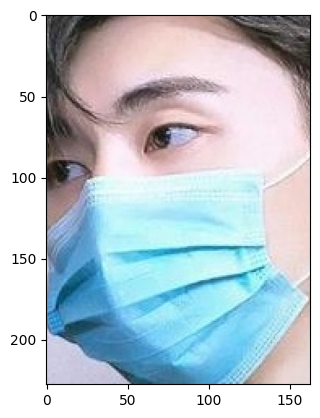

In [27]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_1545.jpg')
imgplot = plt.imshow(img)
plt.show()

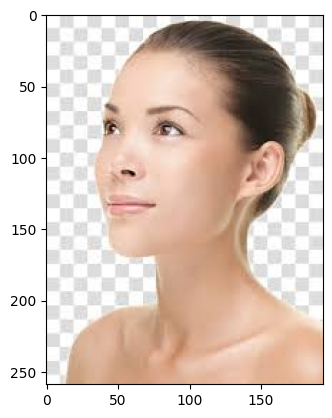

In [28]:
# displaying without mask image
img = mpimg.imread('/content/data/without_mask/without_mask_2925.jpg')
imgplot = plt.imshow(img)
plt.show()

In [29]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [30]:
type(data)

list

In [31]:
len(data)

7553

array([[[226, 213, 207],
        [228, 215, 210],
        [226, 215, 211],
        ...,
        [ 90,  58,  43],
        [ 88,  57,  42],
        [ 92,  64,  48]],

       [[227, 212, 208],
        [228, 214, 210],
        [230, 216, 213],
        ...,
        [ 96,  63,  48],
        [ 89,  59,  44],
        [ 89,  61,  45]],

       [[227, 212, 209],
        [228, 214, 211],
        [230, 216, 215],
        ...,
        [100,  68,  53],
        [ 90,  60,  44],
        [ 91,  63,  46]],

       ...,

       [[219, 202, 215],
        [216, 198, 212],
        [217, 196, 210],
        ...,
        [ 64,  51,  50],
        [ 62,  49,  51],
        [ 60,  49,  52]],

       [[219, 203, 216],
        [218, 201, 215],
        [217, 198, 212],
        ...,
        [ 59,  50,  50],
        [ 56,  47,  50],
        [ 55,  46,  52]],

       [[221, 205, 218],
        [219, 203, 216],
        [218, 200, 214],
        ...,
        [ 56,  50,  49],
        [ 52,  47,  49],
        [ 48,  44,  50]]], dtype=uint8)
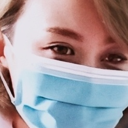

In [32]:
data[0]

In [33]:
type(data[0])

numpy.ndarray

In [34]:
data[0].shape

(128, 128, 3)

In [35]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [36]:
type(X)

numpy.ndarray

In [37]:
type(Y)

numpy.ndarray

In [38]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [39]:
print(Y)

[1 1 1 ... 0 0 0]


In [40]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [41]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [42]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[ 66,  68,  47],
        [ 66,  68,  47],
        [ 66,  68,  47],
        ...,
        [185, 164,  99],
        [184, 163,  98],
        [182, 161,  96]],

       [[ 66,  68,  47],
        [ 66,  68,  47],
        [ 66,  68,  47],
        ...,
        [185, 164,  99],
        [185, 164,  99],
        [187, 166, 101]],

       [[ 66,  68,  47],
        [ 66,  68,  47],
        [ 66,  68,  47],
        ...,
        [187, 166, 101],
        [186, 165, 100],
        [187, 166, 101]],

       ...,

       [[ 91,  94, 103],
        [ 89,  90,  98],
        [ 95,  92,  98],
        ...,
        [108,  98,  99],
        [ 96,  79,  76],
        [119,  93,  83]],

       [[ 92,  91,  97],
        [ 92,  91,  98],
        [ 98,  95, 104],
        ...,
        [101,  92,  92],
        [ 99,  86,  83],
        [112,  93,  87]],

       [[ 89,  87,  87],
        [ 95,  92,  98],
        [102,  98, 109],
        ...,
        [102,  93,  92],
        [ 93,  83,  81],
        [ 87,  76,  75]]], dtype=uint8)
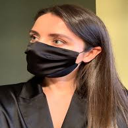

In [43]:
X_train[0]

In [44]:
X_train_scaled[0]

array([[[0.25882353, 0.26666667, 0.18431373],
        [0.25882353, 0.26666667, 0.18431373],
        [0.25882353, 0.26666667, 0.18431373],
        ...,
        [0.7254902 , 0.64313725, 0.38823529],
        [0.72156863, 0.63921569, 0.38431373],
        [0.71372549, 0.63137255, 0.37647059]],

       [[0.25882353, 0.26666667, 0.18431373],
        [0.25882353, 0.26666667, 0.18431373],
        [0.25882353, 0.26666667, 0.18431373],
        ...,
        [0.7254902 , 0.64313725, 0.38823529],
        [0.7254902 , 0.64313725, 0.38823529],
        [0.73333333, 0.65098039, 0.39607843]],

       [[0.25882353, 0.26666667, 0.18431373],
        [0.25882353, 0.26666667, 0.18431373],
        [0.25882353, 0.26666667, 0.18431373],
        ...,
        [0.73333333, 0.65098039, 0.39607843],
        [0.72941176, 0.64705882, 0.39215686],
        [0.73333333, 0.65098039, 0.39607843]],

       ...,

       [[0.35686275, 0.36862745, 0.40392157],
        [0.34901961, 0.35294118, 0.38431373],
        [0.37254902, 0

In [45]:
import tensorflow as tf
from tensorflow import keras

In [46]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [55]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9309 - loss: 0.1818 - val_acc: 0.9140 - val_loss: 0.2963
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - acc: 0.9492 - loss: 0.1334 - val_acc: 0.9074 - val_loss: 0.2563
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - acc: 0.9504 - loss: 0.1287 - val_acc: 0.9157 - val_loss: 0.3005
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - acc: 0.9597 - loss: 0.1046 - val_acc: 0.9174 - val_loss: 0.2766
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9717 - loss: 0.0898 - val_acc: 0.9372 - val_loss: 0.2877
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - acc: 0.9695 - loss: 0.0802 - val_acc: 0.9273 - val_loss: 0.2888
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - acc: 0.9694 - loss: 0.0862 - val_acc: 0.8793 - val_loss: 0.5378
Epoch 8/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - acc: 0.9622 - loss: 0.1036 - val_acc: 0.9207 - val_loss: 0.3455
Epoch 9/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/

In [56]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9083 - loss: 0.3145
Test Accuracy = 0.9265387058258057


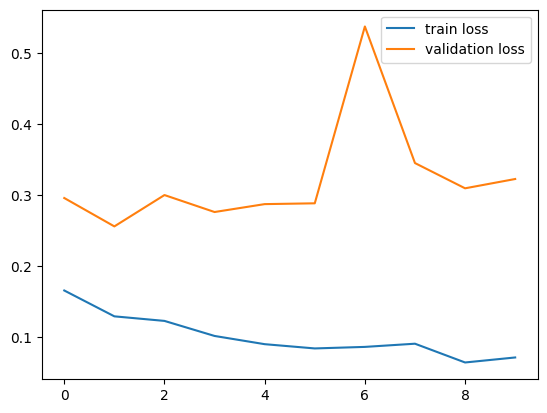

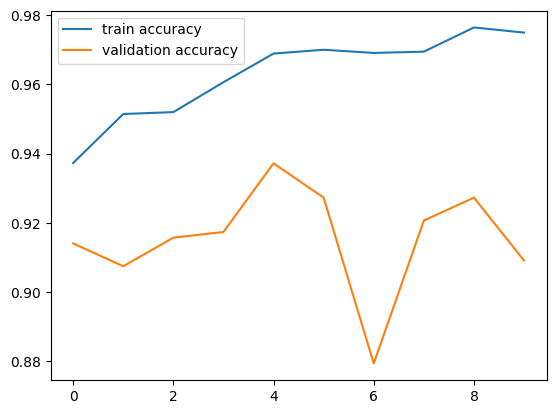

In [57]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

Path of the image to be predicted: /content/with mask.jpeg


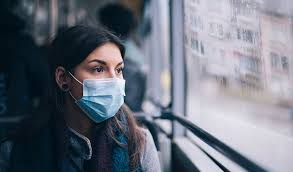

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
[[0.35998666 0.57999593]]
1
The person in the image is wearing a mask


In [65]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

Path of the image to be predicted: /content/ff.jpeg


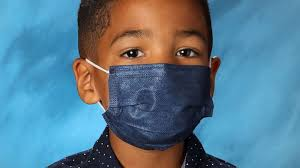

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
[[0.97475713 0.00969816]]
0
The person in the image is  wearing a mask


In [67]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is not wearing a mask')

else:

  print('The person in the image is  wearing a mask')